In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
from itertools import combinations

plt.style.use(['science','notebook'])
import matplotlib
matplotlib.rcParams.update({'font.size': 16})

## Transferability results

In [26]:
n_coords = 150
k = 10 # 30 / 3, to keep same ratio k/N
n_best = 5

variables_train = {}
imbalances_train = {}
imbalances_val1 = {}
imbalances_val2 = {}
for i_fold in range(3):
        variables_train[i_fold], imbalances_train[i_fold], imbalances_val1[i_fold], imbalances_val2[i_fold] = (
            pickle.load(open(f"./pickles_transferability/nbest{n_best}_ncoords{n_coords}_k{k}_fold{i_fold}.p","rb")) 
        )
        print(f"Best 25 features in fold {i_fold}: {variables_train[i_fold][24]}")

Best 25 features in fold 0: [128, 5, 12, 142, 17, 18, 20, 151, 25, 167, 46, 176, 49, 179, 180, 67, 196, 202, 83, 215, 219, 114, 116, 117, 125]
Best 25 features in fold 1: [128, 5, 17, 18, 20, 151, 25, 167, 46, 176, 49, 179, 180, 57, 196, 202, 207, 83, 84, 219, 105, 114, 116, 117, 125]
Best 25 features in fold 2: [128, 142, 17, 18, 20, 151, 25, 167, 46, 176, 49, 179, 180, 57, 196, 202, 207, 83, 215, 105, 113, 114, 116, 117, 125]


In [2]:
from itertools import combinations
# initializing list
test_list = [1, 7, 4, 3]
 
# printing original list 
print("The original list : " + str(test_list))

# All possible pairs in List
# Using combinations()
res = list(combinations(test_list, 2))
res

The original list : [1, 7, 4, 3]


[(1, 7), (1, 4), (1, 3), (7, 4), (7, 3), (4, 3)]

In [3]:
25 * 25

625

### Imbalance vs n_features for train and validation sets

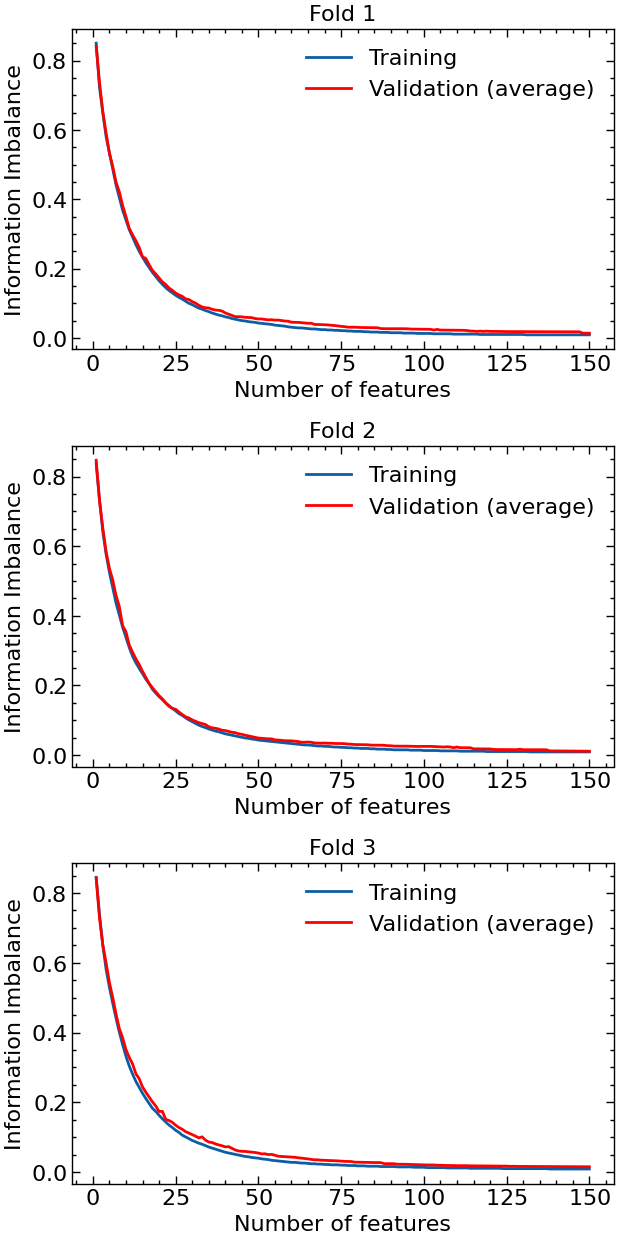

In [12]:
fig, ax = plt.subplots(3,1,figsize=(7,15),gridspec_kw={"hspace": 0.3})

for i_fold in range(3):
    ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_train[i_fold][:,1], '-', label="Training")
    #ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_val1[i_fold][1,:], '-', label="Validation 1")
    #ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_val2[i_fold][1,:], '-', label="Validation 2")
    ax[i_fold].plot(np.arange(1,n_coords+1), 0.5*(imbalances_val1[i_fold][1,:]+imbalances_val2[i_fold][1,:]), '-', color="red", label="Validation (average)")
    ax[i_fold].set(xlabel="Number of features", ylabel="Information Imbalance", title=f"Fold {i_fold+1}")
    ax[i_fold].legend()
plt.savefig("./figures/transferability_imbalances.pdf", dpi=300)
plt.show()


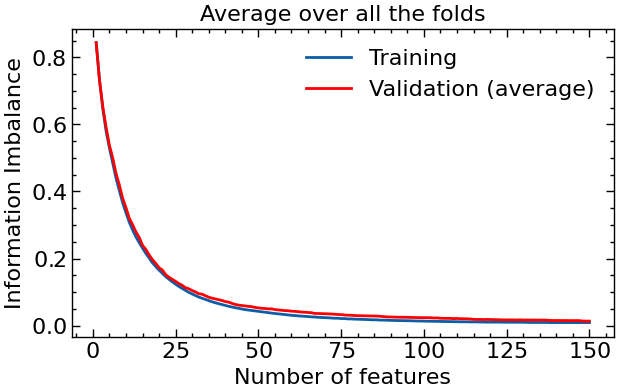

In [9]:
fig, ax = plt.subplots(1,1,figsize=(7,4),gridspec_kw={"hspace": 0.3})

ax.plot(np.arange(1,n_coords+1), (imbalances_train[0][:,1]+imbalances_train[1][:,1]+imbalances_train[2][:,1])/3, '-', label="Training")
ax.plot(np.arange(1,n_coords+1), 0.5*(imbalances_val1[0][1,:]+imbalances_val2[0][1,:]
                                      + imbalances_val1[1][1,:]+imbalances_val2[1][1,:]
                                      + imbalances_val1[2][1,:]+imbalances_val2[2][1,:]) / 3, '-', color="red", label="Validation (average)")
ax.set(xlabel="Number of features", ylabel="Information Imbalance", title=f"Average over all the folds")
ax.legend()
plt.savefig("./figures/transferability_imbalances_average.pdf", dpi=300)
plt.show()


### % common features in three independent trainings

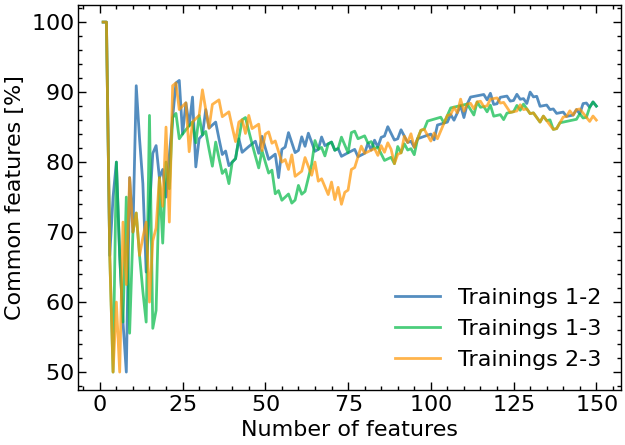

In [10]:
fig, ax = plt.subplots(1,figsize=(7,5))

intersections_12 = np.zeros(n_coords)
intersections_13 = np.zeros(n_coords)
intersections_23 = np.zeros(n_coords)
for i_feat in range(n_coords):
    intersection_train1_train2 = set(variables_train[0][i_feat]).intersection(variables_train[1][i_feat])
    intersection_train1_train3 = set(variables_train[0][i_feat]).intersection(variables_train[2][i_feat])
    intersection_train2_train3 = set(variables_train[1][i_feat]).intersection(variables_train[2][i_feat])
    intersections_12[i_feat] = len(intersection_train1_train2)
    intersections_13[i_feat] = len(intersection_train1_train3)
    intersections_23[i_feat] = len(intersection_train2_train3)
ax.plot(np.arange(1,n_coords+1), intersections_12 / np.arange(1,n_coords+1) * 100, '-', label=f"Trainings 1-2", alpha=0.7)
ax.plot(np.arange(1,n_coords+1), intersections_13 / np.arange(1,n_coords+1) * 100, '-', label=f"Trainings 1-3", alpha=0.7)
ax.plot(np.arange(1,n_coords+1), intersections_23 / np.arange(1,n_coords+1) * 100, '-', label=f"Trainings 2-3", alpha=0.7)
ax.set(xlabel="Number of features", ylabel="Common features [%]")
ax.legend()
plt.savefig("./figures/transferability_features.pdf", dpi=300)
plt.show()

### Matrix of pair-wise imbalances

In [2]:
features, matrix_imb = pickle.load(open("./pickles/matrix_imbalances_ncoords30_k30.p","rb"))
print(np.array(features).shape,np.array(matrix_imb).shape)
print(f"Best 25 features: {features}")

(25,) (25, 25)
Best 25 features: [128, 12, 142, 17, 18, 20, 151, 25, 167, 46, 176, 49, 179, 180, 196, 202, 207, 83, 215, 219, 105, 114, 116, 117, 125]


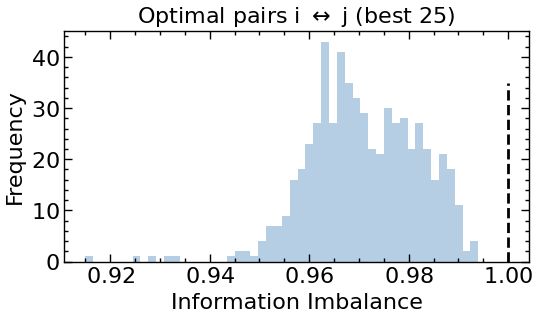

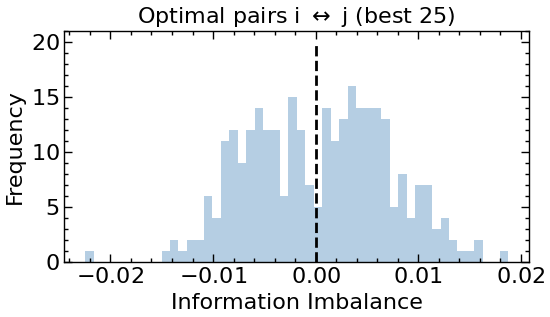

In [3]:
#sorted_imbs = np.sort(np.array(matrix_imb).flatten())
#print(sorted_imbs)

plt.figure(figsize=(6,3))
plt.hist(np.sort(matrix_imb.flatten())[25:],bins=50,alpha=0.3)
plt.vlines(1,0,35,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs i $\\leftrightarrow$ j (best 25)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist((matrix_imb - matrix_imb.T)[np.triu_indices(matrix_imb.shape[0], k=1)],bins=50,alpha=0.3)
#plt.hist((matrix_imb.T - matrix_imb)[np.triu_indices(matrix_imb.shape[0], k=1)],bins=50,alpha=0.3)
plt.vlines(0,0,20,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs i $\\leftrightarrow$ j (best 25)")
plt.show()

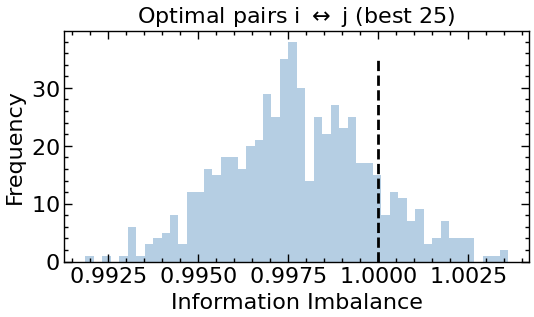

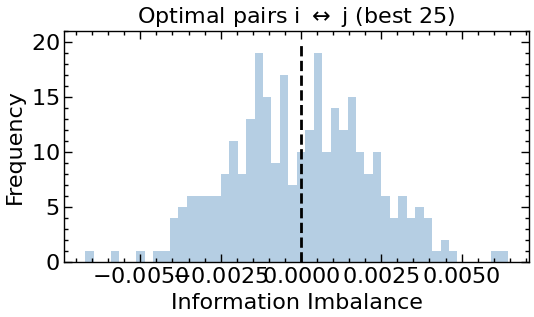

In [ ]:
#sorted_imbs = np.sort(np.array(matrix_imb).flatten())
#print(sorted_imbs)

plt.figure(figsize=(6,3))
plt.hist(np.sort(matrix_imb.flatten())[25:],bins=50,alpha=0.3)
plt.vlines(1,0,35,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs i $\\leftrightarrow$ j (best 25)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist((matrix_imb - matrix_imb.T)[np.triu_indices(matrix_imb.shape[0], k=1)],bins=50,alpha=0.3)
#plt.hist((matrix_imb.T - matrix_imb)[np.triu_indices(matrix_imb.shape[0], k=1)],bins=50,alpha=0.3)
plt.vlines(0,0,20,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs i $\\leftrightarrow$ j (best 25)")
plt.show()

### Imbalances between pairs in optimal subset

In [4]:
imbs = np.zeros((15,2530,2))
for i_parallel in range(15):
    _, imbs[i_parallel] = pickle.load(open(f"./pickles/imbalances_pairs_2plets_ncoords25_k30_iparallel{i_parallel}.p","rb"))

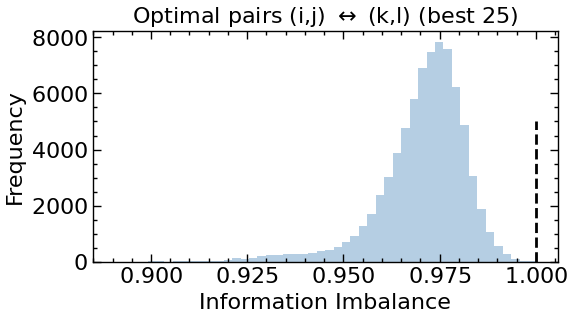

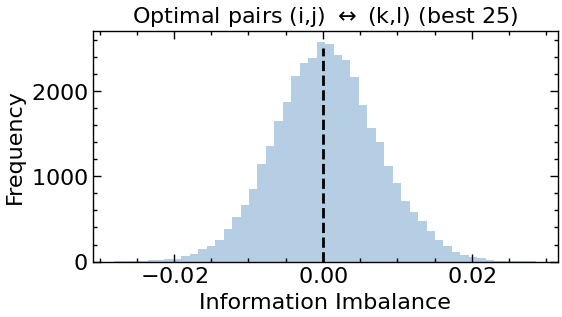

In [5]:
plt.figure(figsize=(6,3))
plt.hist(imbs.flatten(),bins=50,alpha=0.3)
plt.vlines(1,0,5000,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(imbs.reshape((-1,2))[:,0]-imbs.reshape((-1,2))[:,1],bins=50,alpha=0.3)
plt.vlines(0,0,2500,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

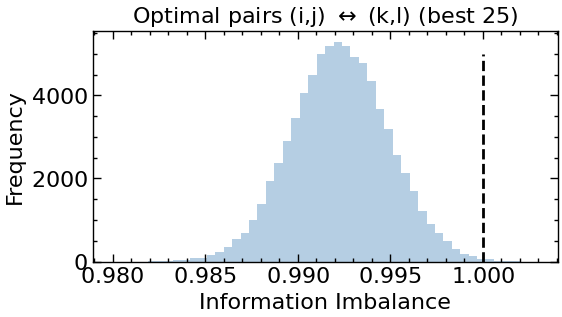

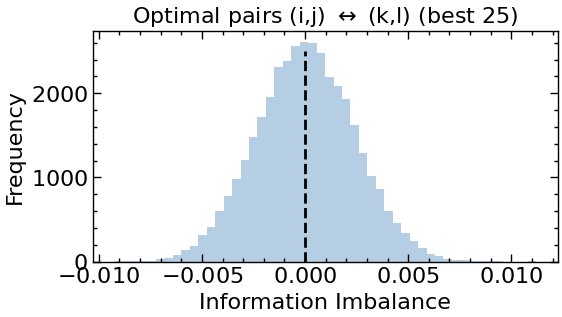

In [ ]:
plt.figure(figsize=(6,3))
plt.hist(imbs.flatten(),bins=50,alpha=0.3)
plt.vlines(1,0,5000,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(imbs.reshape((-1,2))[:,0]-imbs.reshape((-1,2))[:,1],bins=50,alpha=0.3)
plt.vlines(0,0,2500,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

### Imbalances between greedy pairs of 3plets in optimal subset

In [9]:
imbs = np.zeros((10,420,2))
for i_parallel in range(10):
    _, imbs[i_parallel] = pickle.load(open(f"./pickles/imbalances_greedy_pairs_3plets_ncoords25_k30_iparallel{i_parallel}.p","rb"))

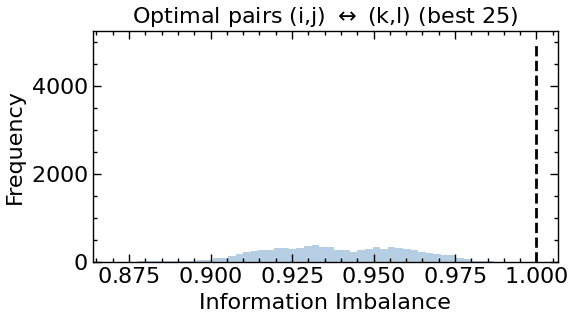

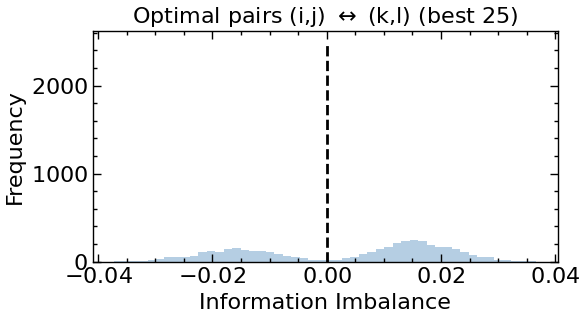

In [8]:
plt.figure(figsize=(6,3))
plt.hist(imbs.flatten(),bins=50,alpha=0.3)
plt.vlines(1,0,5000,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(imbs.reshape((-1,2))[:,0]-imbs.reshape((-1,2))[:,1],bins=50,alpha=0.3)
plt.vlines(0,0,2500,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

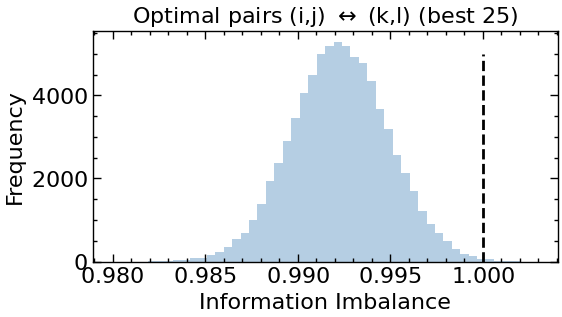

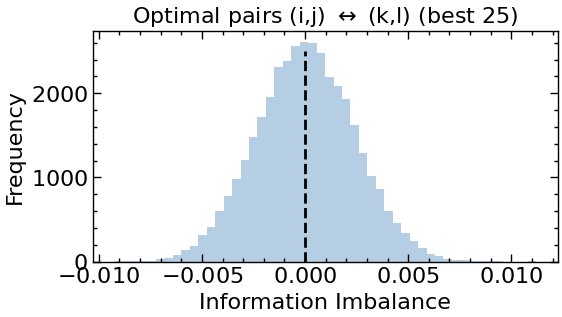

In [ ]:
plt.figure(figsize=(6,3))
plt.hist(imbs.flatten(),bins=50,alpha=0.3)
plt.vlines(1,0,5000,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(imbs.reshape((-1,2))[:,0]-imbs.reshape((-1,2))[:,1],bins=50,alpha=0.3)
plt.vlines(0,0,2500,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Optimal pairs (i,j) $\\leftrightarrow$ (k,l) (best 25)")
plt.show()

### Single best features vs nonoptimal ones

In [2]:
imbalances = np.zeros((25,203,2))
for i_feat, feature_ref in enumerate(range(25)):
    opt_features, imbalances[i_feat] = pickle.load(open(f"./pickles/imbalances_selected{feature_ref}_vs_nonselected_k30.p","rb"))
print(imbalances.shape)

(25, 203, 2)


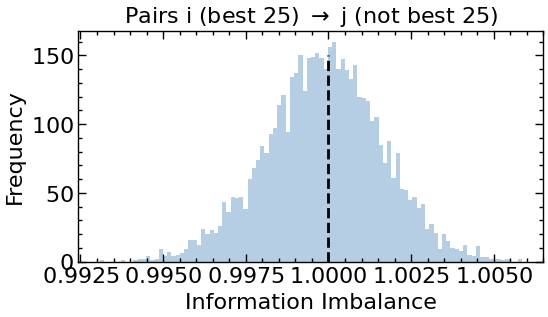

In [13]:
plt.figure(figsize=(6,3))
plt.hist(imbalances[:,:,0].flatten(),bins=100,alpha=0.3)
plt.vlines(1,0,150,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.title("Pairs i (best 25) $\\rightarrow$ j (not best 25)")
plt.show()

In [34]:
test_list = [1,2,3,4,5,6]
print(6*5*4/(3*2))

from itertools import combinations
  
# printing original list 
print("The original list : " + str(test_list))
 
# All possible pairs in List
# Using combinations()
res = list(combinations(test_list, 3))
 
# printing result 
print("All possible pairs : " + str(len(res)))

20.0
The original list : [1, 2, 3, 4, 5, 6]
All possible pairs : 20


In [35]:
3200 * 3199 / 2

5118400.0

In [14]:
feats_25 = np.arange(25)
all_3plets = list(combinations(feats_25, 2))
print(len(all_3plets))

count = 0
for i in np.arange(300):
    for j in np.arange(i+1,300):
        intersection = set(all_3plets[i]).intersection(all_3plets[j])
        if len(intersection) == 0:
            count += 1
print(count)

300
37950


In [3]:
100 / 6

16.666666666666668

In [4]:
12 / 44 * 16.66

4.543636363636363

In [7]:
2300 * 2299 / 2

2643850.0

In [2]:
37950 / 6

6325.0

In [8]:
37950 / 10

3795.0

In [7]:
2530.0 / 10

253.0

### Trials for triplets greedy

In [52]:
features_single, _ = pickle.load(open("./pickles/matrix_imbalances_ncoords30_k30.p","rb"))
all_2plets = np.array(list(combinations(features_single, 2)))
print(all_2plets.shape)

(300, 2)


In [53]:
imbs = np.zeros((6,6325,2))
for i_parallel in range(6):
    features_2plet, imbs[i_parallel] = pickle.load(open(f"./pickles/imbalances_pairs_2plets_ncoords25_k30_iparallel{i_parallel}.p","rb"))
imbs = imbs.reshape((37950,2))

print(features_2plet.shape)

(37950, 2, 2)


In [37]:
# select indices of the 10 2plets pairs that have the most asymmetric information imbalance
indices_largest_diff = np.argsort(np.abs(imbs[:,0] - imbs[:,1]))[-10:] 
print(indices_largest_diff)

[ 6787  2465 29238 31278  7884 19346 29769 23750 15942  5663]


In [61]:
# for each of the 10 pairs of 2plets selected, add one feature to space A and one to space B 
# (distinct to the ones already present) and compute info imbalance between 3plets (25-4)*(25-5) 3plets
all_pairs_of_single_feats = np.array(list(combinations(features_single, 2)))

features_3plet = np.zeros((10*21*20, 2, 3), dtype=int)

index_3plet = 0
for index_of_pair_2plet in indices_largest_diff:
    for new_feat_1, new_feat_2 in all_pairs_of_single_feats:
        if new_feat_1 not in features_2plet[index_of_pair_2plet] and new_feat_2 not in features_2plet[index_of_pair_2plet]:
            features_3plet[index_3plet,0] = np.append(features_2plet[index_of_pair_2plet,0], [new_feat_1])
            features_3plet[index_3plet,1] = np.append(features_2plet[index_of_pair_2plet,1], [new_feat_2])
            features_3plet[index_3plet+1,0] = np.append(features_2plet[index_of_pair_2plet,0], [new_feat_2])
            features_3plet[index_3plet+1,1] = np.append(features_2plet[index_of_pair_2plet,1], [new_feat_1])
            index_3plet += 2

In [81]:
10*21*20 / 10

420.0